In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
from utils import *

### var est  for mean

In [2]:
# Parameters
sim_n = 2000 
n = 100      
B = 200
seed = 42

# Arrays to store results
var_jackknife_sim = np.zeros(sim_n)
var_boot_sim = np.zeros(sim_n)

# Simulation
with ProcessPoolExecutor() as executor:
    futures = [
        executor.submit(simulate_mean, 
                        i=i, 
                        n=n, 
                        B=B, 
                        seed=seed)
        for i in range(sim_n)
    ]
    
    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        var_jackknife_sim[i], var_boot_sim[i] = future.result()

Simulations: 100%|██████████| 2000/2000 [00:01<00:00, 1060.78simulation/s]


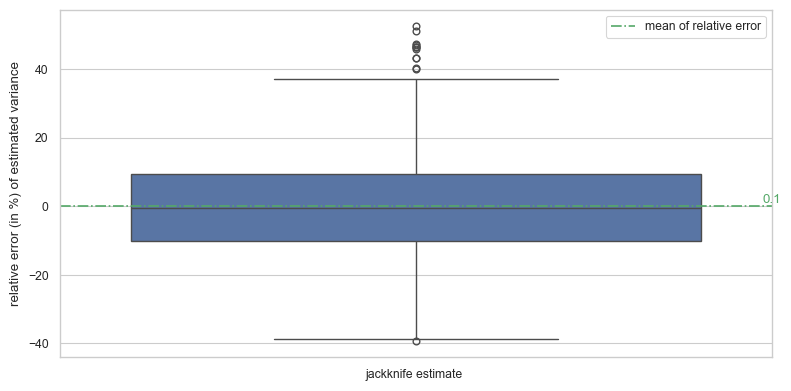

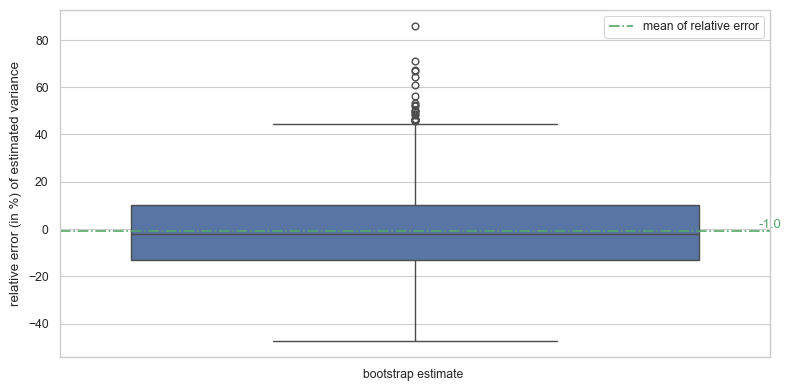

In [3]:
# plot jackkknife
df = pd.DataFrame({'jackknife estimate ': var_jackknife_sim})
plt.figure(figsize=(8, 4))
sns.set_theme(context='paper',style="whitegrid") 
sns.boxplot(data=(df-1/n)/(1/n)*100) 
plt.axhline(y=np.mean((df-1/n)/(1/n)*100), color='g', linestyle='dashdot', label='mean of relative error')  
plt.ylabel('relative error (in %) of estimated variance')
plt.text(0.5, np.mean((df-1/n)/(1/n)*100), f'{np.mean((df-1/n)/(1/n)*100):.1f}', color='g', ha='center', va='bottom')
plt.legend()
#plt.ylim(-0.4, 0.4)
plt.tight_layout()
plt.savefig("boxplot_JK_linear_mean.png", dpi = 1000)
plt.show()

# plot bootstrap
df = pd.DataFrame({'bootstrap estimate ': var_boot_sim})
plt.figure(figsize=(8, 4))
sns.set_theme(context='paper',style="whitegrid") 
sns.boxplot(data=(df-1/n)/(1/n)*100) 
plt.axhline(y=np.mean((df-1/n)/(1/n)*100), color='g', linestyle='dashdot', label='mean of relative error')  
plt.text(0.5, np.mean((df-1/n)/(1/n)*100), f'{np.mean((df-1/n)/(1/n)*100):.1f}', color='g', ha='center', va='bottom')
plt.ylabel('relative error (in %) of estimated variance')
plt.legend()
#plt.ylim(-0.4, 0.4)
plt.tight_layout()
plt.savefig("boxplot_boot_linear_mean.png", dpi = 1000)
plt.show()

### var est for pearson correlation coefficient

In [4]:
# Parameters
mean = [0, 0]
p = 0.7
cov = [[1, p], [p, 1]]

sim_n = 2_000
n = 400
B = 200
seed = 42

var_jackknife = np.zeros(sim_n)
var_boot = np.zeros(sim_n)

# Simulation
with ProcessPoolExecutor() as executor:
    futures = [
        executor.submit(simulate_pearson, 
                        mean=mean, 
                        cov=cov, 
                        n=n, 
                        B=B, 
                        sim_i=i, 
                        seed=seed)
        for i in range(sim_n)
    ]
    
    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        var_jackknife[i], var_boot[i] = future.result()

# True std for the correlation https://www.jstor.org/stable/pdf/2277400.pdf?refreqid=fastly-default%3Aef46e66363b4ca95a1a81b2e1b6d92f0&ab_segments=&origin=&initiator=&acceptTC=1
true_var_corr = ((1 - p**2) / np.sqrt(n)) ** 2

Simulations: 100%|██████████| 2000/2000 [00:20<00:00, 96.41simulation/s] 


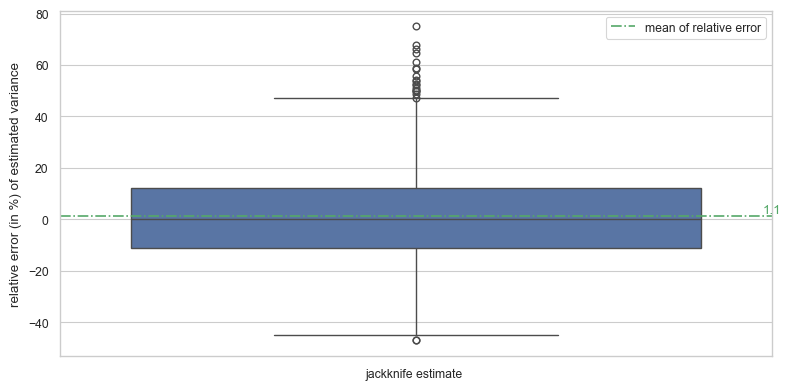

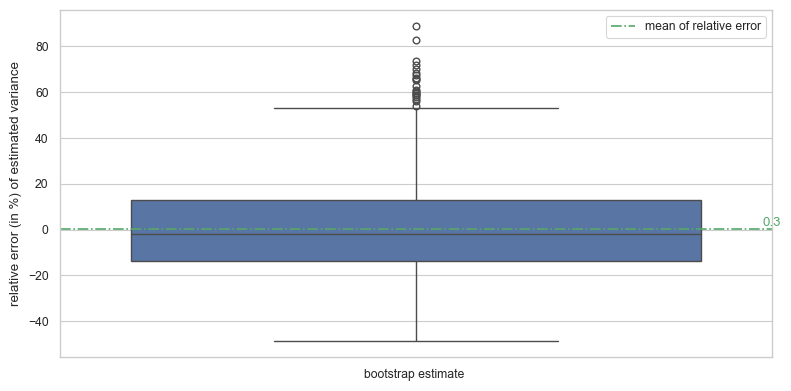

In [5]:

# plot jackknife
df = pd.DataFrame({'jackknife estimate ': var_jackknife})
plt.figure(figsize=(8, 4))
sns.set_theme(context='paper',style="whitegrid") 
sns.boxplot(data=(df-true_var_corr)/true_var_corr*100) 
plt.axhline(y=np.mean((df-true_var_corr)/true_var_corr*100), color='g', linestyle='dashdot', label='mean of relative error')  
plt.text(0.5, np.mean((df-true_var_corr)/(true_var_corr)*100), f'{np.mean((df-true_var_corr)/(true_var_corr)*100):.1f}', color='g', ha='center', va='bottom')
plt.ylabel('relative error (in %) of estimated variance')
plt.legend()
#plt.ylim(-0.6, 1.4)
plt.tight_layout()
plt.savefig("boxplot_jk_non_linear_corr.png", dpi = 1000)
plt.show()

# plot bootstrap
df2 = pd.DataFrame({'bootstrap estimate ': var_boot})
plt.figure(figsize=(8,4))
sns.set_theme(context='paper',style="whitegrid") 
sns.boxplot(data=(df2-true_var_corr)/true_var_corr*100) 
plt.axhline(y=np.mean((df2-true_var_corr)/true_var_corr*100), color='g', linestyle='dashdot', label='mean of relative error')  
plt.text(0.5, np.mean((df2-true_var_corr)/(true_var_corr)*100), f'{np.mean((df2-true_var_corr)/(true_var_corr)*100):.1f}', color='g', ha='center', va='bottom')
plt.ylabel('relative error (in %) of estimated variance')
plt.legend()
#plt.ylim(-0.6, 1.4)
plt.tight_layout()
plt.savefig("boxplot_boot_non_linear_corr.png", dpi = 1000)
plt.show()

### var est of median

In [6]:
# Parameters
sim_n = 2_000
n = 400
B = 200
seed = 42

var_jackknife = np.zeros(sim_n)
var_boot = np.zeros(sim_n)
var_emp = np.zeros(sim_n)

# Simulation
with ProcessPoolExecutor() as executor:
    futures = [
        executor.submit(simulate_median, 
                        n=n,
                        B=B, 
                        sim_i=i, 
                        seed=seed)
        for i in range(sim_n)
    ]
    
    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        var_jackknife[i], var_boot[i], var_emp[i] = future.result()
        
var_emp = np.var(var_emp)
        

Simulations: 100%|██████████| 2000/2000 [00:04<00:00, 416.30simulation/s]


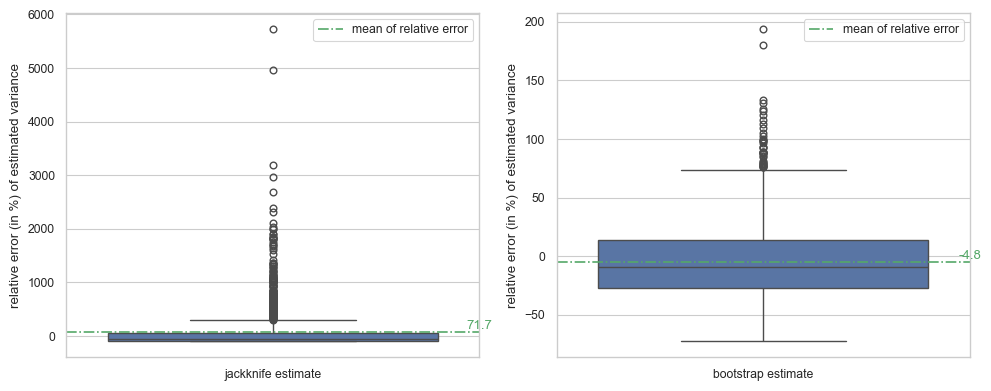

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assuming var_jackknife, var_boot, and emp_var are already defined

# Create the dataframes
df_jackknife = pd.DataFrame({'jackknife estimate': var_jackknife})
df_bootstrap = pd.DataFrame({'bootstrap estimate': var_boot})

rel_error_jackknife = (df_jackknife['jackknife estimate'] - var_emp) / var_emp
df_rel_error_jackknife = pd.DataFrame({'jackknife estimate': rel_error_jackknife})

rel_error_bootstrap = (df_bootstrap['bootstrap estimate'] - var_emp) / var_emp
df_rel_error_bootstrap = pd.DataFrame({'bootstrap estimate': rel_error_bootstrap})

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot jackknife
sns.set_theme(context='paper', style='whitegrid')
sns.boxplot(data=df_rel_error_jackknife*100, ax=axes[0])
axes[0].axhline(y=np.mean(df_rel_error_jackknife)*100, color='g', linestyle='dashdot', label='mean of relative error')
mean_value = np.mean(df_rel_error_jackknife)
axes[0].text(0.5, mean_value*100, f'{mean_value*100:.1f}', color='g', ha='center', va='bottom')
axes[0].set_ylabel('relative error (in %) of estimated variance')
axes[0].legend()

# Plot bootstrap
mean_value = np.mean(df_rel_error_bootstrap)
sns.boxplot(data=df_rel_error_bootstrap*100, ax=axes[1])
axes[1].axhline(y=np.mean(df_rel_error_bootstrap)*100, color='g', linestyle='dashdot', label='mean of relative error')
axes[1].text(0.5, mean_value*100, f'{mean_value*100:.1f}', color='g', ha='center', va='bottom')
axes[1].set_ylabel('relative error (in %) of estimated variance')
#axes[1].set_ylim(-0.4, 0.4)
axes[1].legend()
plt.tight_layout()


# Save and show the figure
plt.savefig("boxplot_jk_vs_boot_non_linear_estimator_median.png", dpi=1000)
plt.show()
